In [ ]:
# Import Required Libraries
# These libraries are used for data manipulation, model building, and visualization
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load Training and Test Data
# Read the CSV files from the data directory
data_dir = Path('data')
train_df = pd.read_csv(data_dir / 'train.csv')
test_df = pd.read_csv(data_dir / 'test.csv')
train_df.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


In [ ]:
# Display All Available Features
# Print the column names to understand what features are available in the dataset
all_features = train_df.columns.tolist()
print(all_features)

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [ ]:
# Feature Engineering for Test Data
# Create new features: total area and total bathrooms by combining related columns
test_df['Total_Area'] = test_df['GrLivArea'] + test_df['TotalBsmtSF']
test_df['Total_Baths'] = test_df['FullBath'] + (0.5 * test_df['HalfBath']) + test_df['BsmtFullBath'] + (0.5 * test_df['BsmtHalfBath'])

In [ ]:
# Feature Engineering for Training Data
# Apply the same transformations to create total area and total bathrooms features
train_df['Total_Area'] = train_df['GrLivArea'] + train_df['TotalBsmtSF']
train_df['Total_Baths'] = train_df['FullBath'] + (0.5 * train_df['HalfBath']) + train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath'])

In [ ]:
# Define Features and Target Variable
# Select the features (input variables) and target variable (output to predict)
features = ['BedroomAbvGr', 'Total_Area' , 'Total_Baths']
target = 'SalePrice'

In [ ]:
# Prepare Training and Test Data
# Fill missing values with median values from the training set and prepare feature matrices
X_train_full = train_df[features].fillna(train_df[features].median())
y_train_full = train_df[target]

X_test_final = test_df[features].fillna(train_df[features].median())

In [ ]:
# Split Data into Training and Validation Sets
# Divide the full training data into training (80%) and validation (20%) sets for model evaluation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [ ]:
# Handle Missing Values
# Fill any empty cells with the median value of each feature from the training data
# Create a list of the features
features = ['BedroomAbvGr', 'Total_Area', 'Total_Baths']

# Fill any empty cells with the median value of the training data
for col in features:
    median_value = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_value)
    test_df[col] = test_df[col].fillna(median_value)

print("Missing values successfully filled!")

Missing values successfully filled!


In [ ]:
# Train Model and Evaluate Performance
# Initialize a linear regression model, train it on the training data, and evaluate on validation data
# Initialize the model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model performance on our validation set
y_val_pred = model.fit(X_train, y_train).predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print(f"Validation Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Validation R² Score: {r2:.4f}")

Validation Root Mean Squared Error (RMSE): $46,299.04
Validation R² Score: 0.7205


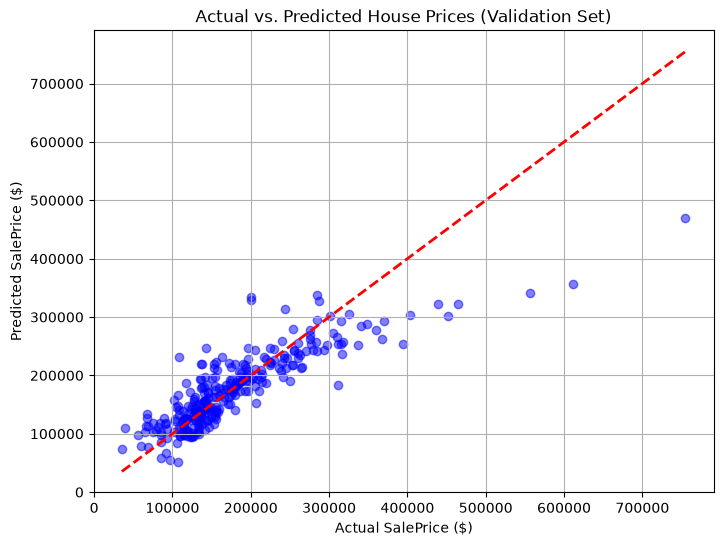

In [ ]:
# Visualize Actual vs. Predicted Prices
# Create a scatter plot comparing predicted prices to actual prices on the validation set
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred, alpha=0.5, color='blue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs. Predicted House Prices (Validation Set)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.grid(True)
plt.show()

In [ ]:
# Generate Predictions on Test Set
# Use the trained model to make predictions on the actual Kaggle test dataset
test_predictions = model.predict(X_test_final)

In [ ]:
# Create Results DataFrame and Display Predictions
# Combine the house IDs with their predicted prices and display the first 15 results
# Generate predictions using the cleaned test data features
test_predictions = model.predict(test_df[features])

# Combine the House IDs with their newly predicted prices
results_df = pd.DataFrame({
    'House_Id': test_df['Id'],
    'Predicted_SalePrice': test_predictions
})

# Display the first 15 predictions to see what the model guessed
print("--- Model Guesses for Unseen Test Data ---")
print(results_df.head(15))

--- Model Guesses for Unseen Test Data ---
    House_Id  Predicted_SalePrice
0       1461        110278.529313
1       1462        164754.849136
2       1463        185579.893845
3       1464        183931.599368
4       1465        185008.908228
5       1466        177094.229684
6       1467        186743.652744
7       1468        167082.366932
8       1469        203449.235167
9       1470        136414.745116
10      1471        223110.520978
11      1472        104971.206189
12      1473        101203.939841
13      1474        170562.099718
14      1475        103807.447291
